# Stack Overflow Survey 2025 EDA


**Business question:**

What factors contribute to or justify a higher compensation ? 

**Hypotheses:**

The group would like to know if the following factors results to higher salary and if there are actions that a developer can take to improve it

* Geography e.g. continent, country 
* Job position
* Technical Skillset
* Source of learning e.g. University, Bootcamp
* Level of education
* AI knowledge
* Working Remote

## Import libraries and load dataset

In [478]:
# Importing necessary libraries
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
from pathlib import Path
import numpy as np
from scipy import stats
from scipy.stats import shapiro
import missingno as msno

In [479]:
# Setting the path to the dataset
PATH = "../survey_results_public.csv"

In [480]:
# Loading the dataset into a DataFrame
df = pd.read_csv(PATH)

C:\Users\ReDI\AppData\Local\Temp\ipykernel_14376\3191969852.py:2: DtypeWarning: Columns (56,74,92,97,98,105,109,110,132,162,165) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(PATH)


## Dataset general info

In [481]:
# Displaying the first few rows of the DataFrame
df.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchestration,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,Vertex AI,NaN,NaN,NaN,ChatGPT,NaN,When I don’t trust AI’s answers,"Troubleshooting, profiling, debugging",61256.0,10.0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers;When I want to...,All skills. AI is a flop.,104413.0,9.0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code;GitHub Copilot;Google Gemini,NaN,When I don’t trust AI’s answers;When I want to...,"Understand how things actually work, problem s...",53061.0,8.0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,ChatGPT;Claude Code,NaN,When I don’t trust AI’s answers;When I want to...,NaN,36197.0,6.0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,When I don’t trust AI’s answers,"critical thinking, the skill to define the tas...",60000.0,7.0


In [482]:
# Displaying the summary information of the DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49191 entries, 0 to 49190
Columns: 172 entries, ResponseId to JobSat
dtypes: float64(52), int64(1), object(119)
memory usage: 64.6+ MB


In [483]:
# Displaying the shape of the DataFrame
df.shape

(49191, 172)

In [484]:
# Displaying the summary statistics of the DataFrame
df.describe()

,ResponseId,WorkExp,YearsCode,TechEndorse_1,TechEndorse_2,TechEndorse_3,TechEndorse_4,TechEndorse_5,TechEndorse_6,TechEndorse_7,...,SO_Actions_3,SO_Actions_4,SO_Actions_5,SO_Actions_6,SO_Actions_9,SO_Actions_7,SO_Actions_10,SO_Actions_15,ConvertedCompYearly,JobSat
count,49191.000000,42893.000000,43042.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,35975.000000,...,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,26260.000000,2.394700e+04,26670.000000
mean,24596.000000,13.367403,16.570861,7.867352,4.104211,4.110271,5.678193,4.119388,5.225990,6.477387,...,5.718355,4.561767,4.790861,5.199657,5.676314,4.984653,7.099505,10.079284,1.017615e+05,7.201950
std,14200.362883,10.800117,11.787610,2.397432,2.275821,2.329536,2.398084,2.437945,2.801045,2.331468,...,2.628016,3.070548,2.643177,2.563562,2.310659,2.490095,2.469394,1.940928,4.617569e+05,1.997245
min,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000e+00,0.000000
25%,12298.500000,5.000000,8.000000,7.000000,2.000000,2.000000,4.000000,2.000000,3.000000,5.000000,...,3.000000,1.000000,3.000000,3.000000,4.000000,3.000000,6.000000,10.000000,3.817100e+04,6.000000
50%,24596.000000,10.000000,14.000000,9.000000,4.000000,4.000000,6.000000,4.000000,5.000000,7.000000,...,6.000000,4.000000,5.000000,5.000000,6.000000,5.000000,8.000000,10.000000,7.532000e+04,8.000000
75%,36893.500000,20.000000,24.000000,9.000000,6.000000,6.000000,8.000000,6.000000,8.000000,8.000000,...,8.000000,7.000000,7.000000,7.000000,7.000000,7.000000,9.000000,10.000000,1.205960e+05,8.000000
max,49191.000000,100.000000,100.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,14.000000,...,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,15.000000,5.000000e+07,10.000000


**Insights**
* Total Entries: 49191
* Number of Columns: 172
* Max values for WorkExp, YearsCode, ToolcountWork, and ToolCountPersonal are probably invalid




## Missing Values and Response Rates


In [485]:
# check number of rows with invalid ConvertedCompYearly
df_results = df.copy()                         # numeric 0 or 0.0

col = 'ConvertedCompYearly'
mask = (
    df_results[col].isna()
)
count = mask.sum()
print("Number of rows with NaN as value in ConvertedCompYearly:", count)

# check if there can be other invalid values in ConvertedCompYearly other than NaN
mask = (
    df_results[col].eq(0)                               # numeric 0 or 0.0
    | (df_results[col].astype(str).str.strip() == '')   # empty string or spaces
)

count = mask.sum()
print("Number of rows with 0 or empty space as value in ConvertedCompYearly:", count)

Number of rows with NaN as value in ConvertedCompYearly: 25244
Number of rows with 0 or empty space as value in ConvertedCompYearly: 0


<Axes: >

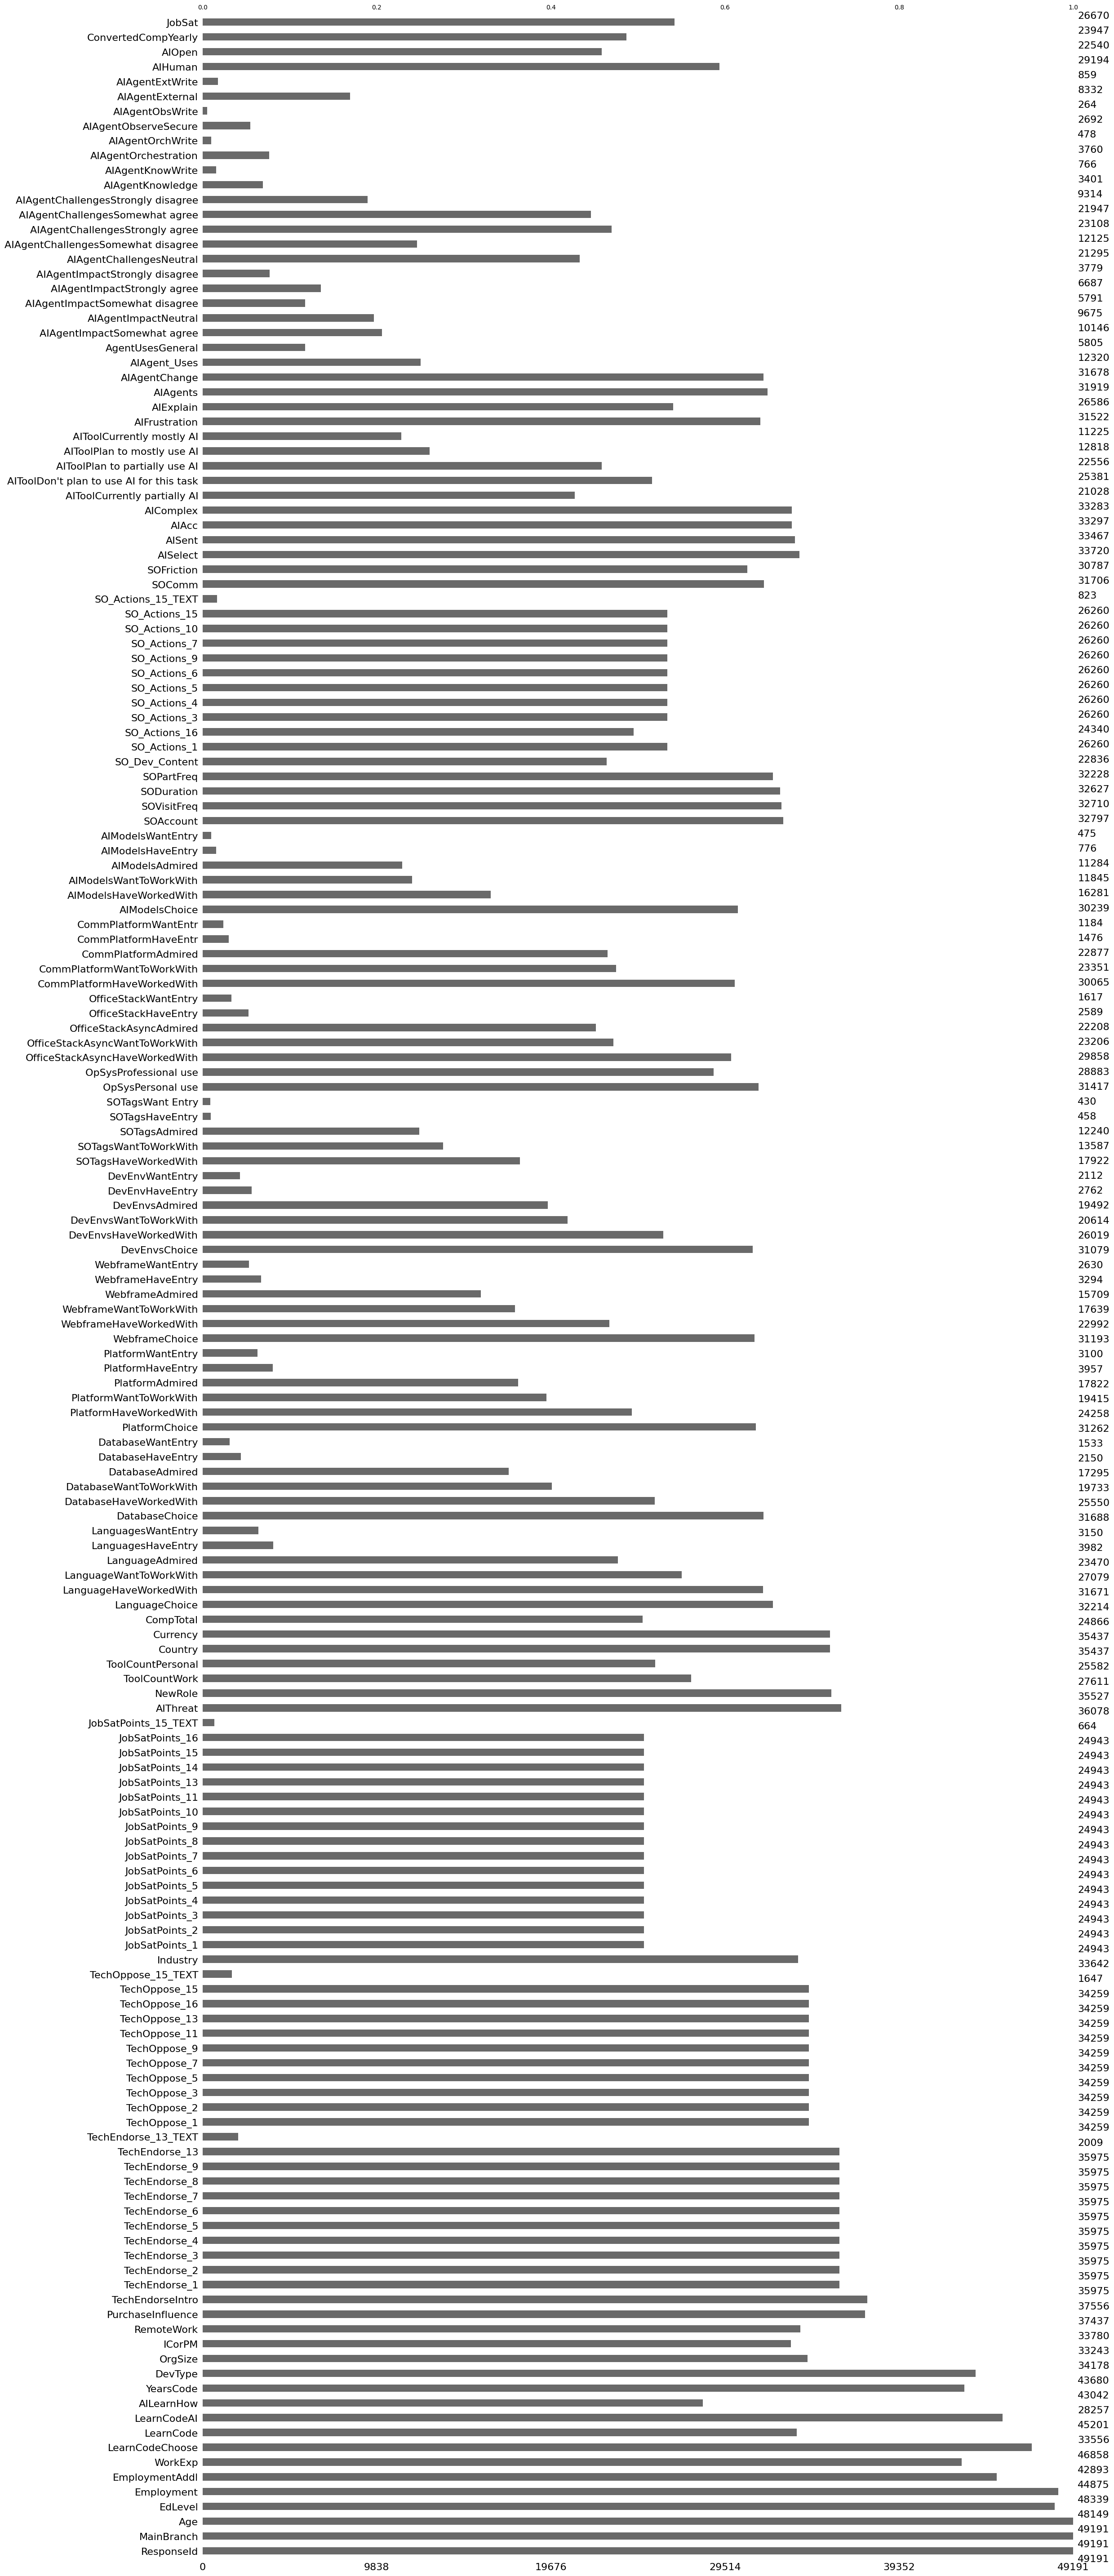

In [486]:
msno.bar(df_results)

<Axes: >

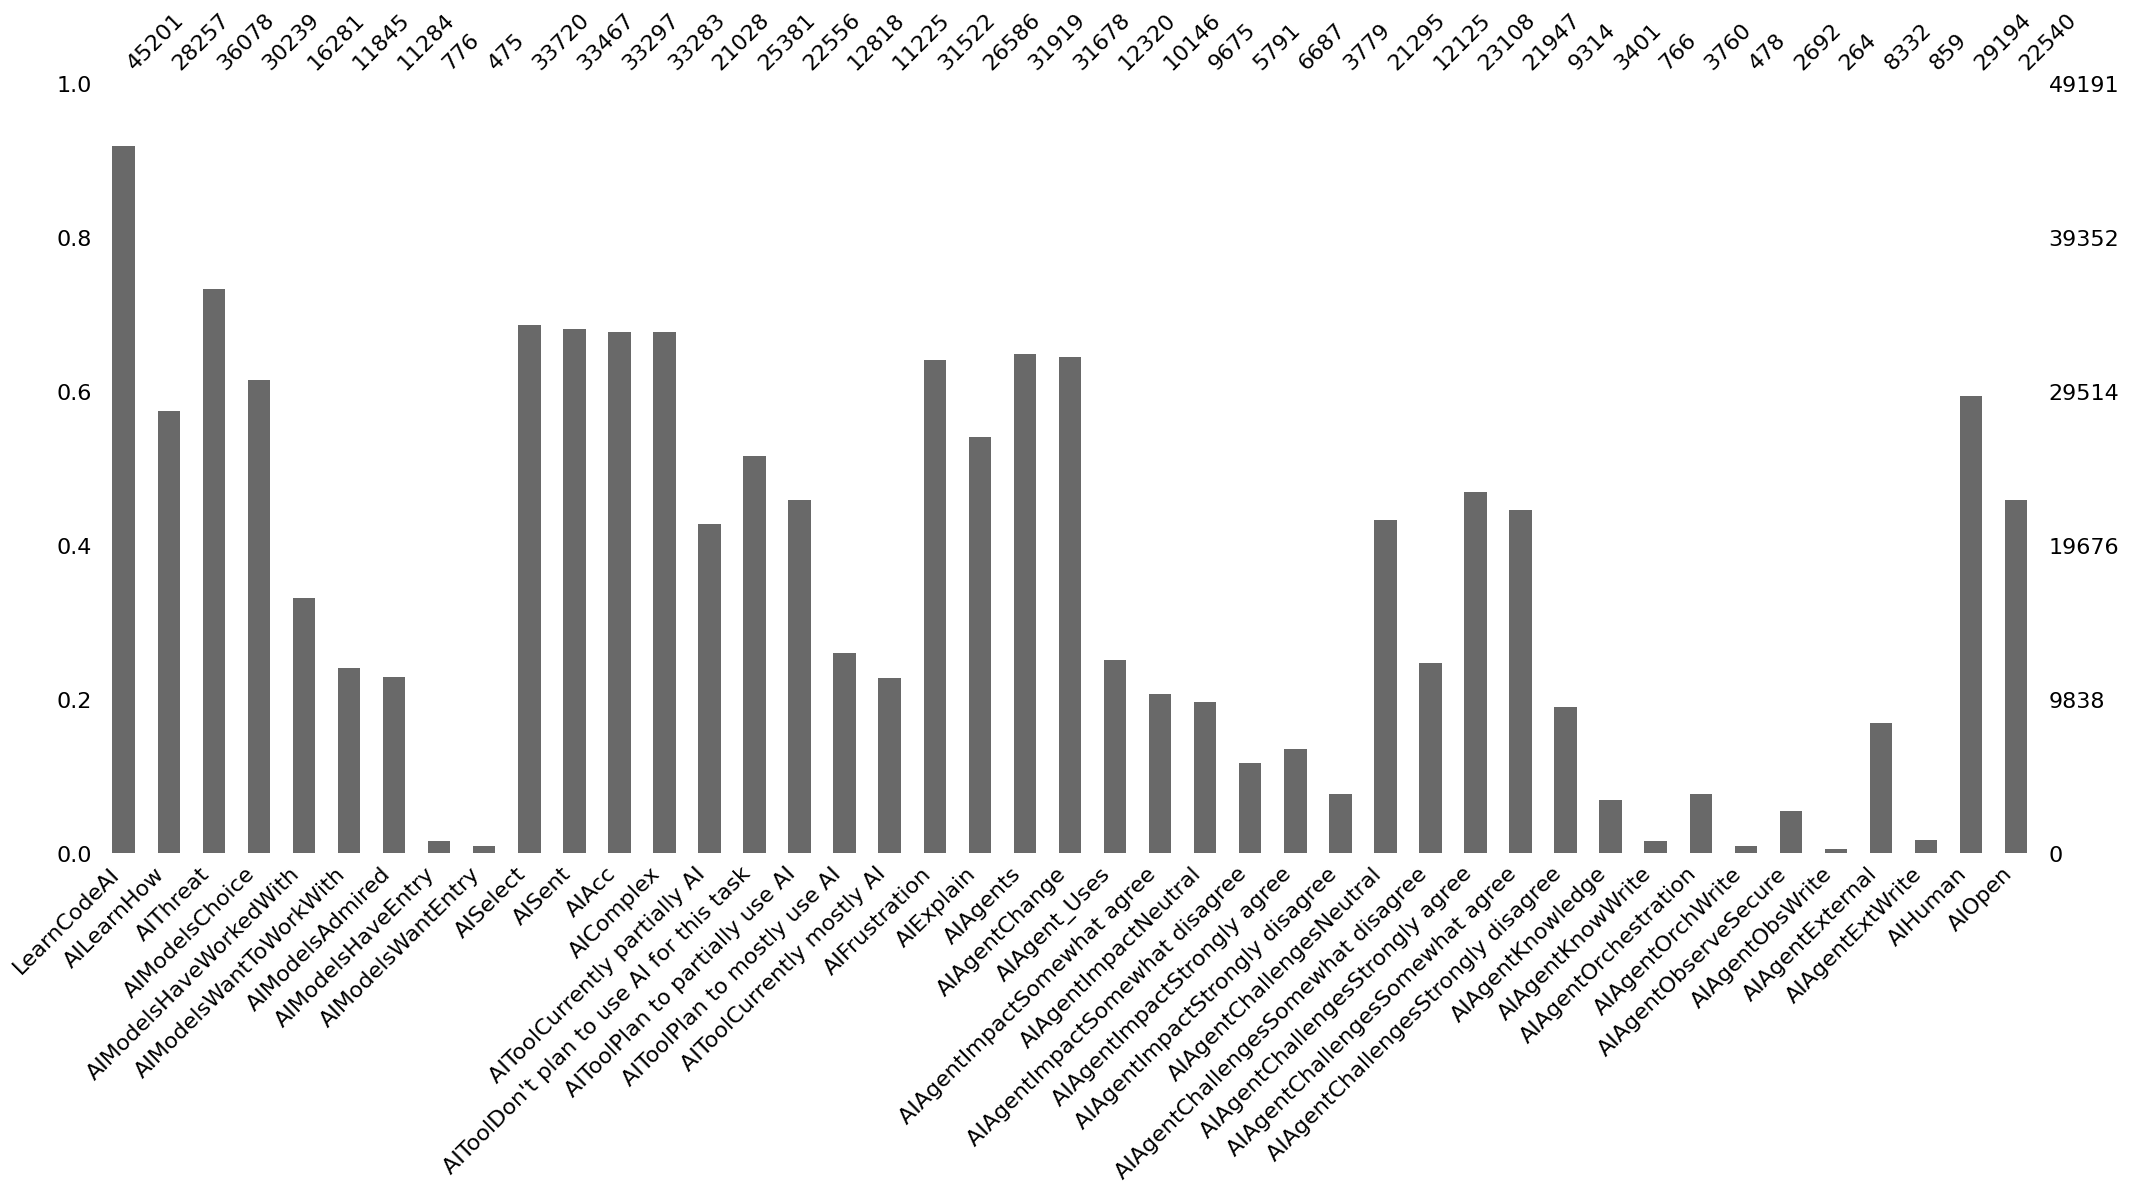

In [487]:
# Response rate of AI related questions
prefix = 'AI'
cols = df_results.filter(like=prefix).columns  # or: df.columns[df.columns.str.startswith(prefix)]
msno.bar(df_results[cols])

In [488]:
# check the number of records with either Currency or CompTotal missing
cols = ["Currency", "CompTotal"]
count = df_results[cols].isna().any(axis=1).sum()
print("Number of records with either one of Currency and CompTotal missing:", count)

# check the number of records with both Currency or CompTotal missing
count = df_results[cols].isna().all(axis=1).sum()
print("Number of records with both Currency and CompTotal missing:", count)

Number of records with either one of Currency and CompTotal missing: 24325
Number of records with both Currency and CompTotal missing: 13754


**Insights**


ConvertedCompYearly has 51.32% of its value missing while CompTotal which ConvertedCompYearly is supposed to be based on has only 49.45% missing.  These additional samll amounts of missing values (1.87%) in ConvertedCompYearly could be due to missing values in the Currency field (even if CompTotal has value or vice versa) or other errors during conversion.

A lot of AI-related questions have low (e.g. less than 30%) response from the participants.  Perhaps a feature can be developed in Sprint 2 to check if there are significant differences in pay between developers who responds to AI vs. those who didn't.

Next we check the distribution of our target prediction value on compensation ConvertedCompYearly.


## Analyse Columns

### ConvertedCompYearly

<Axes: xlabel='ConvertedCompYearly'>

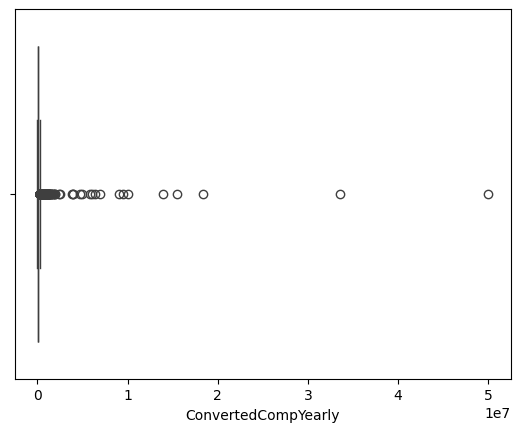

In [489]:
sns.boxplot(data=df, x="ConvertedCompYearly")

In [490]:
# check if distribution of ConvertedCompYearly in the original, full data set is normal with Shapiro-Wilk test
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=UserWarning)
    stat, p = shapiro(df_results['ConvertedCompYearly'], nan_policy='omit')     # omit missing values
    print("*** Shapiro-Wilk Test")
    print(f"Statistic: {stat:.4f}, p-value: {p:.4f}")
    if p > 0.05:
        print("Fail to reject null hypothesis - ConvertedCompYearly data looks normal.")
    else:
        print("Reject null hypothesis - ConvertedCompYearly data does not look normal.")

*** Shapiro-Wilk Test
Statistic: 0.0570, p-value: 0.0000
Reject null hypothesis - ConvertedCompYearly data does not look normal.


In [491]:
skew_before = df_results['ConvertedCompYearly'].dropna().skew()
print('skewness:', skew_before)

skewness: 75.50179550127024


In [492]:
print("ConvertedCompYearly Median:", df_results["ConvertedCompYearly"].dropna().agg("median"))
print("ConvertedCompYearly Mean:", df_results["ConvertedCompYearly"].dropna().agg("mean"))




ConvertedCompYearly Median: 75320.0
ConvertedCompYearly Mean: 101761.53990061386


In [493]:
#get middle 50% of the data for ConvertedCompYearly
lower_middle = df_results['ConvertedCompYearly'].quantile(0.25)
upper_middle = df_results['ConvertedCompYearly'].quantile(0.75)
print("Lower Middle 50%:", lower_middle)
print("Upper Middle 50%:", upper_middle)


Lower Middle 50%: 38171.0
Upper Middle 50%: 120596.0


**Insights**

* ConvertedCompYearly Median: 75320.0 
* ConvertedCompYearly Mean: 101761.53990061386
* Lower Middle 50%: 38171.0
* Upper Middle 50%: 120596.0

ConvertedCompYearly is extremely skewed to the right.
The values accross countries vary greatly.
Going forward we select only a subset of data that is releavnt to our business question e.g. compensation in the DACH region, with factors that a developer can have agency on. 

### Country


In [546]:

df['Country'].value_counts().head(10)

Country
United States of America                                7233
Germany                                                 3025
India                                                   2547
United Kingdom of Great Britain and Northern Ireland    2042
France                                                  1409
Canada                                                  1305
Ukraine                                                  964
Poland                                                   888
Netherlands                                              867
Italy                                                    835
Name: count, dtype: int64

Text(0.5, 1.0, 'Distribution of Respondents by Country (Top 10)')

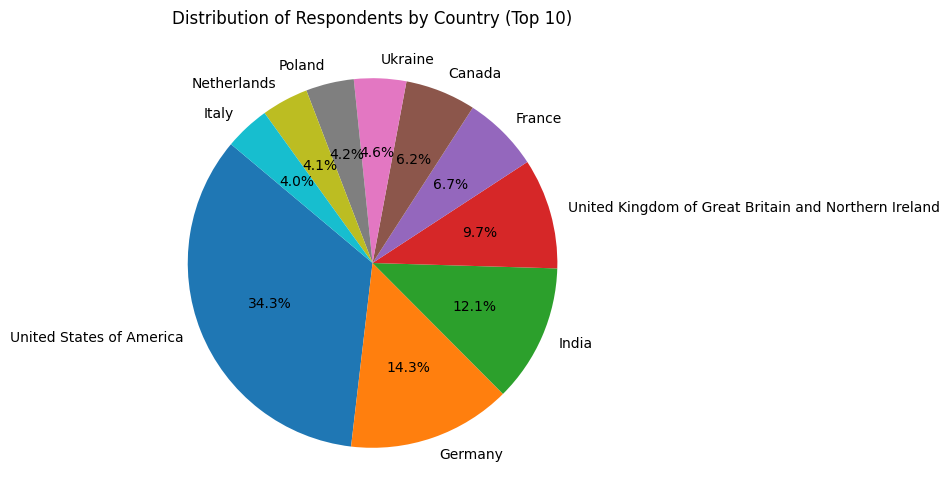

In [495]:
#distribution with percentage of respondents by top 10 countries
country_counts = df['Country'].value_counts().head(10)
plt.figure(figsize=(10, 6))
plt.pie(country_counts, labels=country_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Respondents by Country (Top 10)")


In [496]:

df.groupby("Country")[["ConvertedCompYearly"]].median().sort_values(by="ConvertedCompYearly", ascending=False).round(2)


,ConvertedCompYearly
Country,
Oman,390135.0
North Korea,233924.5
Andorra,200125.5
United States of America,150000.0
Switzerland,142592.0
...,...
Palau,NaN
San Marino,NaN
Sierra Leone,NaN


**Insights**

Countries with most responders: USA, Germany, India, UK, and France
Geographic location plays a role in median salary

### MainBranch

In [497]:
# Chercking value counts of the "MainBranch" column
df["MainBranch"].value_counts()

MainBranch
I am a developer by profession                                                                37467
I am not primarily a developer, but I write code sometimes as part of my work/studies          4894
I am learning to code                                                                          2585
I code primarily as a hobby                                                                    1924
I used to be a developer by profession, but no longer am                                       1325
I work with developers or my work supports developers but am not a developer by profession      996
Name: count, dtype: int64

In [498]:
# Checking for missing values in the "MainBranch" column
df["MainBranch"].isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribution of Respondents by Main Coding Role')

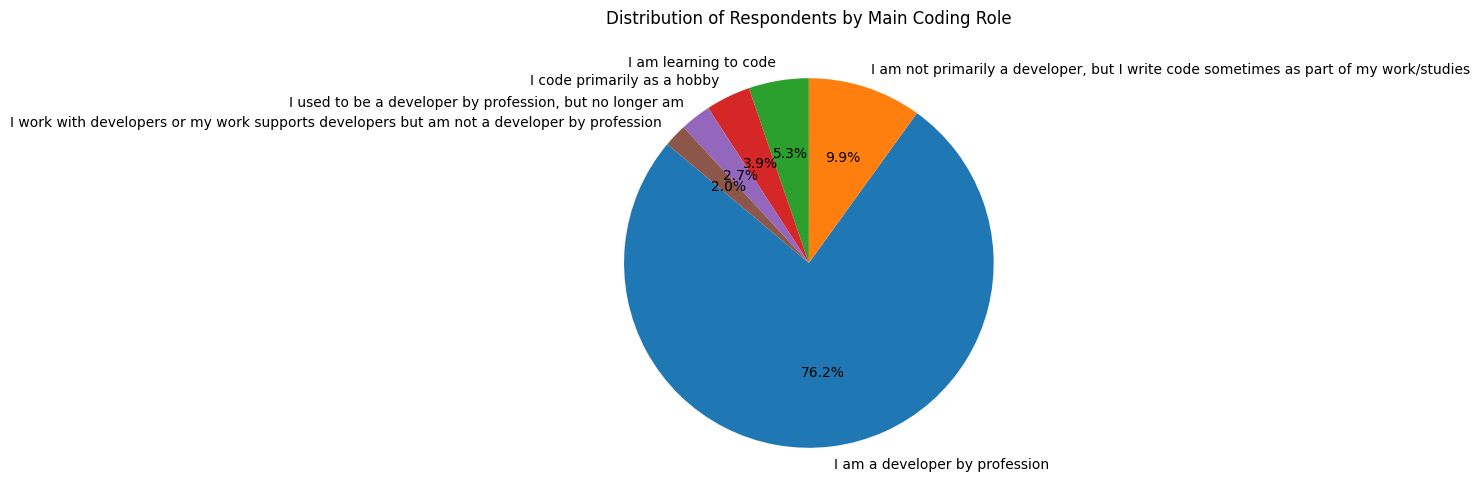

In [499]:
#distribution of respondents by their main coding role with percentage
plt.figure(figsize=(10, 6))
mb_counts = df["MainBranch"].value_counts() 
plt.pie(mb_counts, labels=mb_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Respondents by Main Coding Role")


Text(0.5, 0, 'Number of Respondents')

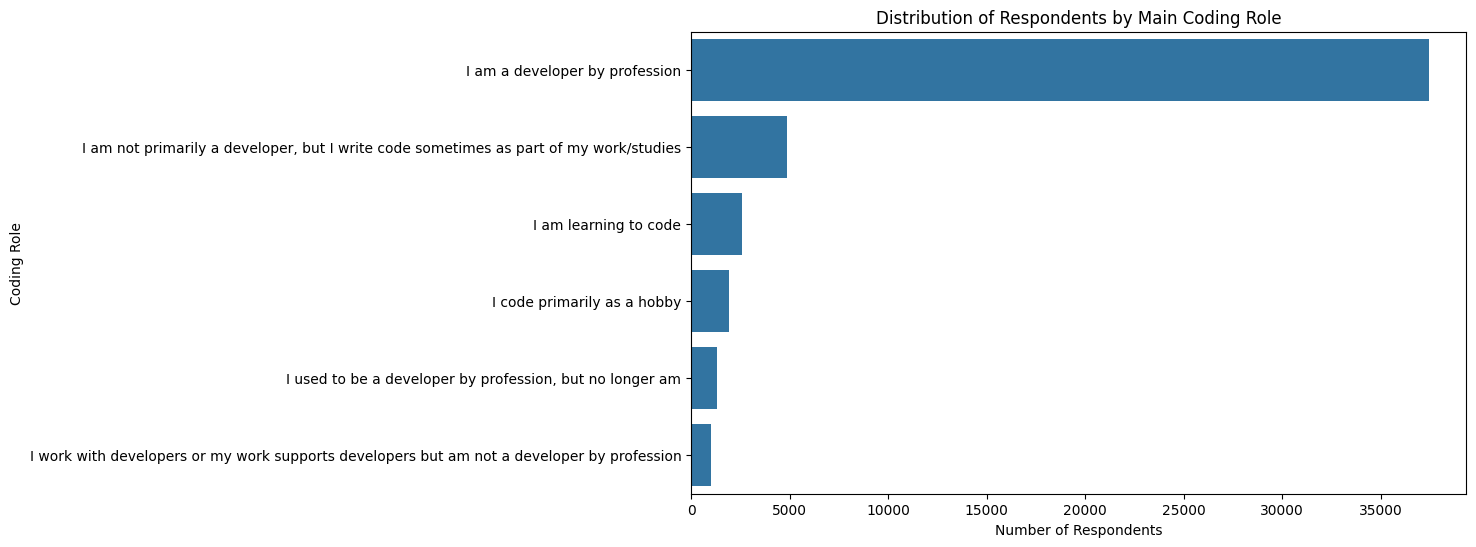

In [500]:
# Visualizing the distribution of respondents by their main coding role with percentage
plt.figure(figsize=(10, 6))
mb_order = df["MainBranch"].value_counts().index

sns.countplot(data=df, y="MainBranch", order=mb_order)

plt.title("Distribution of Respondents by Main Coding Role")
plt.ylabel("Coding Role")
plt.xlabel("Number of Respondents")

**Insights**


Most of Responders are developers by profession: 37467 (76%)
Those who write code sometimes and students: 4894 (10%)

### Age

In [501]:
# Checking value counts of the "Age" column
df["Age"].value_counts()

Age
25-34 years old      16519
35-44 years old      13241
18-24 years old       9210
45-54 years old       6275
55-64 years old       2626
65 years or older      942
Prefer not to say      378
Name: count, dtype: int64

In [502]:
# Checking for missing values in the "Age" column
df["Age"].isnull().sum()

np.int64(0)

Text(0.5, 1.0, 'Distribution of Respondents by Age')

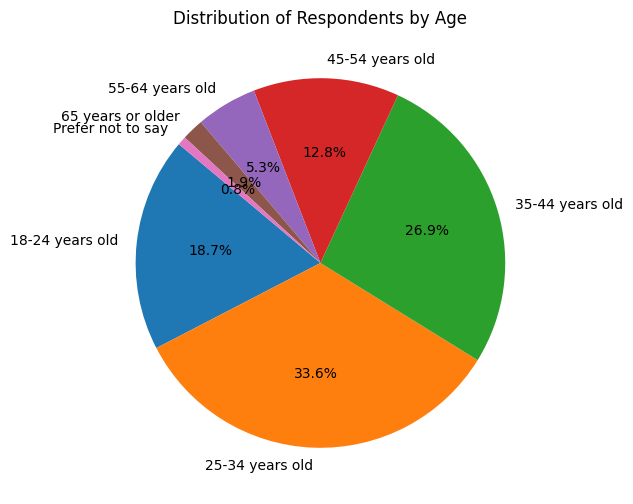

In [503]:
#distibution of age with percentage
plt.figure(figsize=(10, 6))
age_counts = df["Age"].value_counts().sort_index()          
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%", startangle=140)
plt.title("Distribution of Respondents by Age")


Text(0, 0.5, 'Number of Respondents')

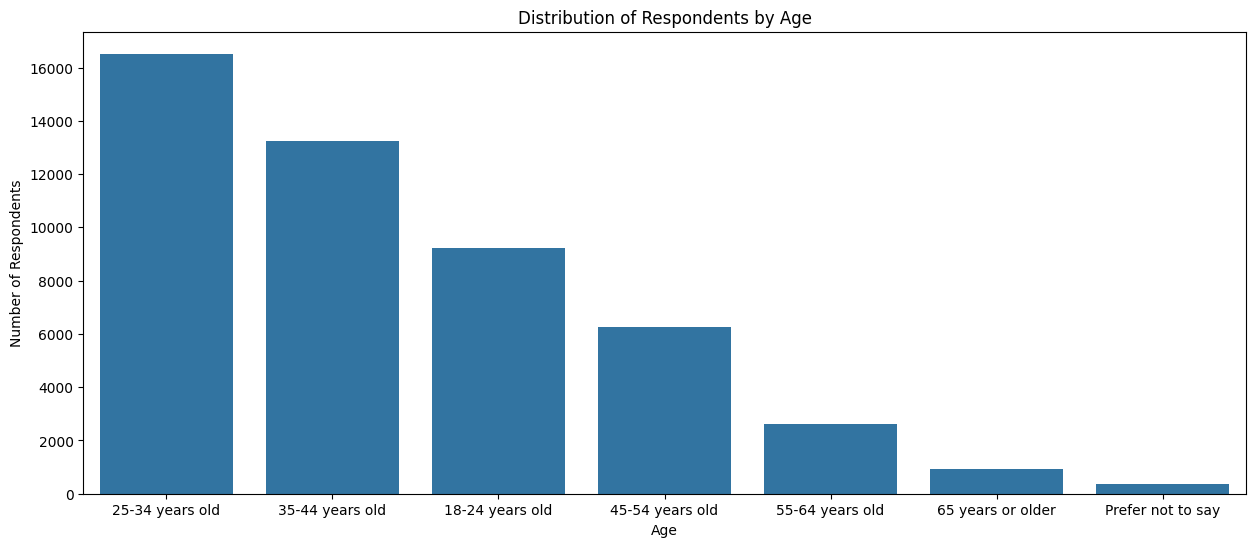

In [504]:
# Visualizing the distribution of respondents by age
plt.figure(figsize=(15, 6))
sns.countplot(data=df, x="Age", order=df["Age"].value_counts().index)
plt.title("Distribution of Respondents by Age")
plt.xlabel("Age")
plt.ylabel("Number of Respondents")

In [505]:
#median ConvertedCompYearly by age
df.groupby("Age")[["ConvertedCompYearly"]].median().sort_values(by="Age", ascending=True).round(2)


,ConvertedCompYearly
Age,
18-24 years old,21350.0
25-34 years old,62648.0
35-44 years old,92812.0
45-54 years old,102142.0
55-64 years old,107198.0
65 years or older,93825.5
Prefer not to say,76479.0


**Insights**


most respondents are between 25-44 years old
25-34: 33.6%
35-44: 26.9%
18-24: 18.7%

Median salaries are increasing with Age and peaks at 55-64 years old


### EdLevel

In [506]:
# Checking value counts of the "EdLevel" column
df["EdLevel"].value_counts()

EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          20278
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       12589
Some college/university study without earning a degree                                 6182
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     3631
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         2624
Associate degree (A.A., A.S., etc.)                                                    1562
Other (please specify):                                                                 701
Primary/elementary school                                                               582
Name: count, dtype: int64

In [507]:
# Checking for missing values in the "EdLevel" column
df["EdLevel"].isnull().sum()

np.int64(1042)

Not so many. 

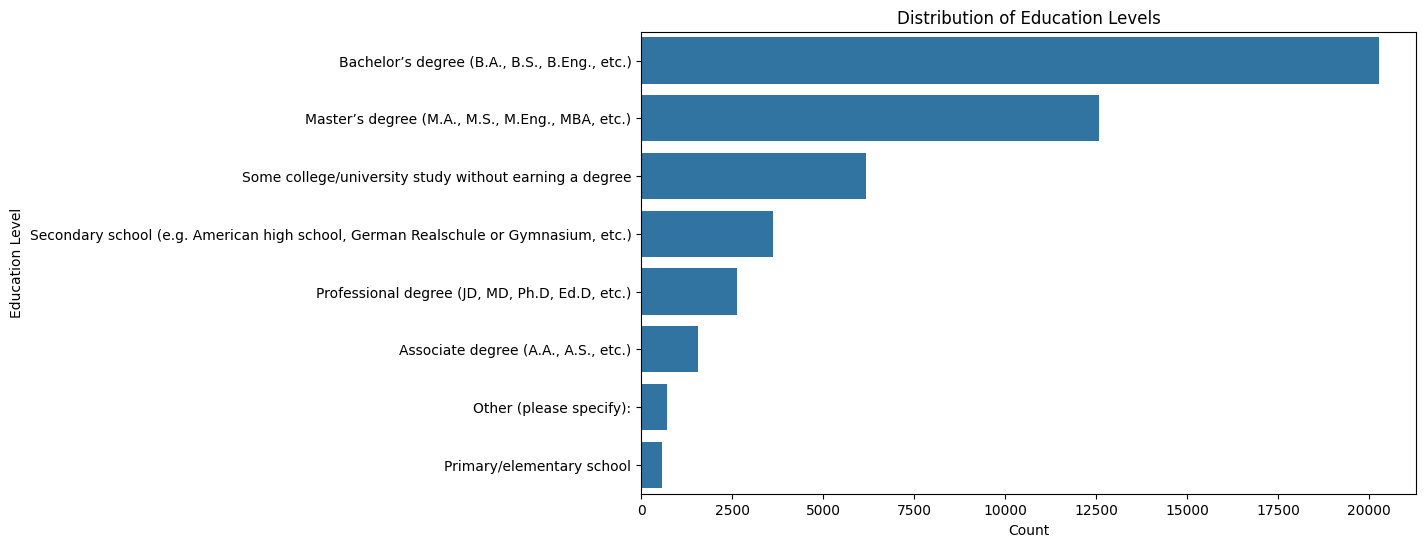

In [508]:
# Visualizing the distribution of education levels among respondents
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="EdLevel", order=df["EdLevel"].value_counts().index)
plt.title("Distribution of Education Levels")
plt.xlabel("Count")
plt.ylabel("Education Level")
plt.show()

In [509]:
df.groupby("EdLevel")[["ConvertedCompYearly"]].median().sort_values(by="ConvertedCompYearly", ascending=False).round(2)

,ConvertedCompYearly
EdLevel,
"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",87011.0
"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",80000.0
"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",75744.0
"Associate degree (A.A., A.S., etc.)",69680.0
Some college/university study without earning a degree,65986.0
"Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)",52207.0
Other (please specify):,49943.0
Primary/elementary school,46646.0


**Insights**

So mostly people have Bachelor's or Master's degree.
Higher Edlevel shows higher median salary, however the increase is not drastic

### Employement

In [547]:
print(df["Employment"].value_counts())

Employment
Employed                                                33750
Independent contractor, freelancer, or self-employed     6708
Student                                                  4428
Not employed                                             2227
Retired                                                   708
I prefer not to say                                       518
Name: count, dtype: int64


In [511]:
df["Employment"].isnull().sum()

np.int64(852)

Text(0.5, 1.0, 'Distribution of Employment Status')

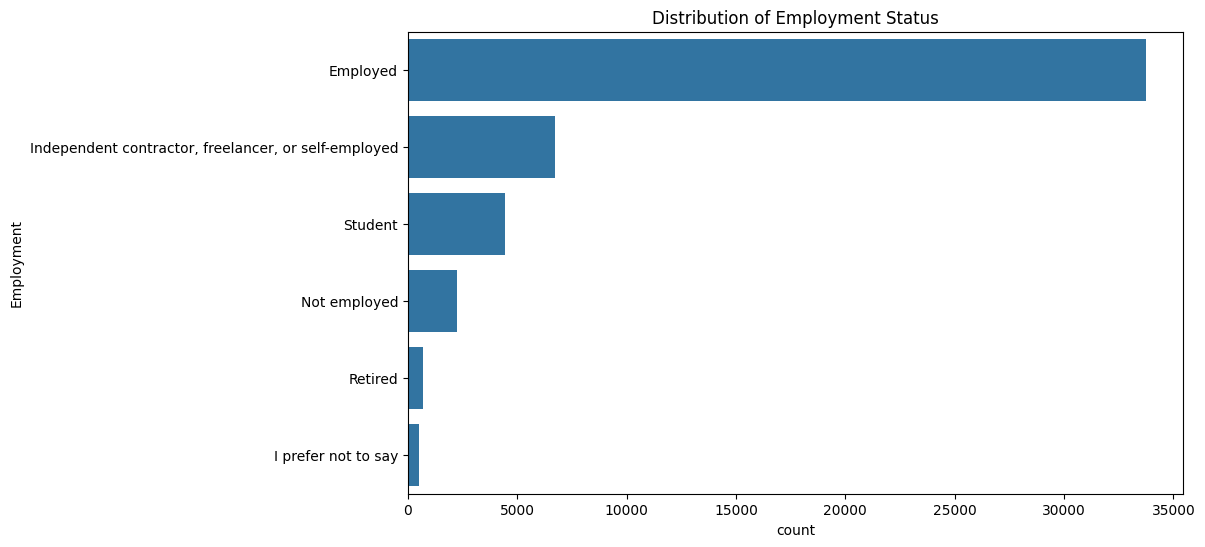

In [512]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="Employment", order=df["Employment"].value_counts().index)
plt.title("Distribution of Employment Status")

**Insights**
* A big majority of respondents are employed or freelaner
* * Employed                                                33750
* * Independent contractor, freelancer, or self-employed     6708
* * Student                                                  4428

### EmploymentAddl

In [513]:
df["EmploymentAddl"].value_counts()

EmploymentAddl
None of the above                                                                                                                                             18613
Caring for dependents (children, elderly, etc.)                                                                                                                5315
Engaged in paid work (20-29 hours per week)                                                                                                                    4725
Attending school (full-time)                                                                                                                                   2763
Volunteering (regularly)                                                                                                                                       2512
                                                                                                                                                              ...  
N

It is lists of additional employments. Have to split it. 

In [514]:
df["EmploymentAddl"].isna().sum()

np.int64(4316)

In [515]:
df_eda = df.copy()

In [516]:
empl_addl_dummies = df_eda['EmploymentAddl'].str.get_dummies(sep=';')
empl_addl_dummies.head()


,Attending school (full-time),Attending school (part-time),"Caring for dependents (children, elderly, etc.)",Engaged in paid work (10-19 hours per week),Engaged in paid work (20-29 hours per week),Engaged in paid work (less than 10 hours per week),None of the above,Transitioning to retirement (gradually reducing work hours),Volunteering (regularly)
0,0,0,1,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,1,0,0
3,0,0,0,0,0,0,1,0,0
4,0,0,1,0,0,0,0,0,0


In [517]:
df_eda = pd.concat([df_eda, empl_addl_dummies], axis=1)
df_eda.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,JobSat,Attending school (full-time),Attending school (part-time),"Caring for dependents (children, elderly, etc.)",Engaged in paid work (10-19 hours per week),Engaged in paid work (20-29 hours per week),Engaged in paid work (less than 10 hours per week),None of the above,Transitioning to retirement (gradually reducing work hours),Volunteering (regularly)
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,10.0,0,0,1,0,0,0,0,0,0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,9.0,0,0,0,0,0,0,0,0,0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,8.0,0,0,0,0,0,0,1,0,0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,6.0,0,0,0,0,0,0,1,0,0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,7.0,0,0,1,0,0,0,0,0,0


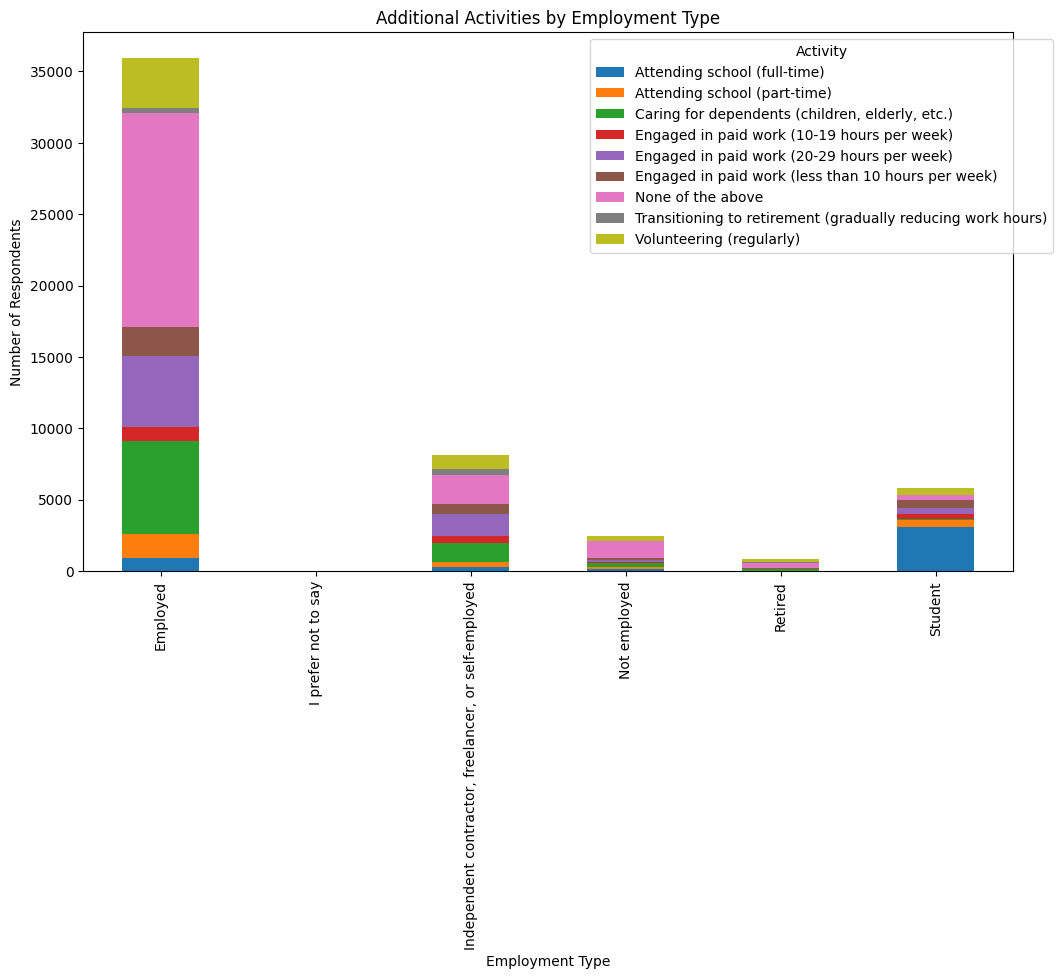

In [518]:
activity_by_employment = df_eda.groupby('Employment')[empl_addl_dummies.columns].sum()

activity_by_employment.plot(
    kind='bar',
    stacked=True,
    figsize=(12, 7)
)

plt.title("Additional Activities by Employment Type")
plt.xlabel("Employment Type")
plt.ylabel("Number of Respondents")
plt.legend(title="Activity", bbox_to_anchor=(1.05, 1))

Text(0.5, 1.0, 'Percentage of Respondents Engaged in Each Additional Activity')

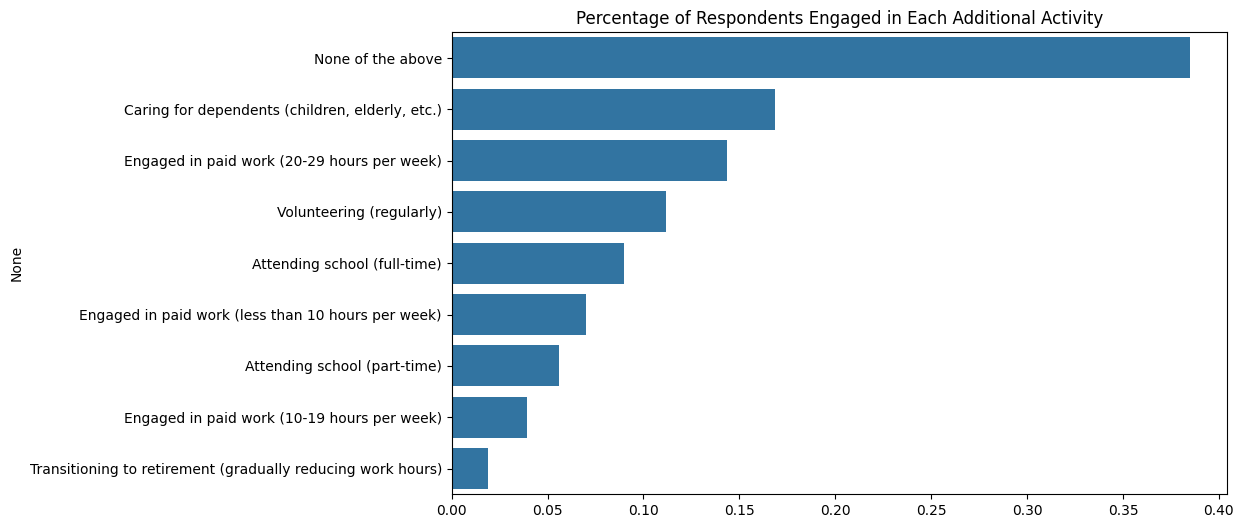

In [519]:
activity_pct = df_eda[empl_addl_dummies.columns].mean().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=activity_pct.values, y=activity_pct.index)
plt.title("Percentage of Respondents Engaged in Each Additional Activity")

Text(0, 0.5, 'Number of Respondents')

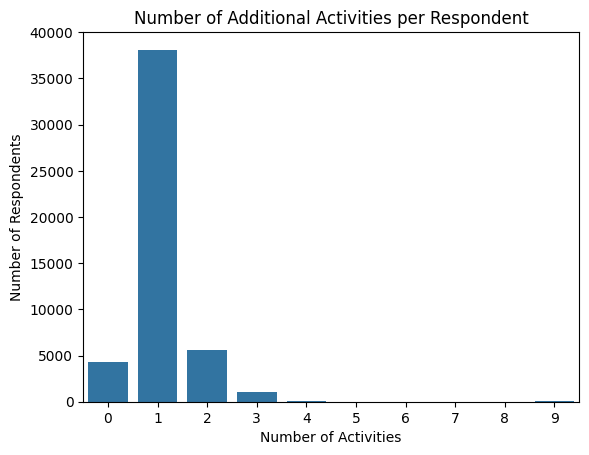

In [520]:

df_eda['num_activities'] = df_eda[empl_addl_dummies.columns].sum(axis=1)
sns.countplot(data=df_eda, x='num_activities')
plt.title("Number of Additional Activities per Respondent")
plt.xlabel("Number of Activities")
plt.ylabel("Number of Respondents")

**Insights**
* 50% of all employed people have other activities, like volunteering, caring for dependents and so on. Students usually are just studying, though 50% are working, volunteering as well.  

### WorkExp

In [521]:
df_eda["WorkExp"].isna().sum()

np.int64(6298)

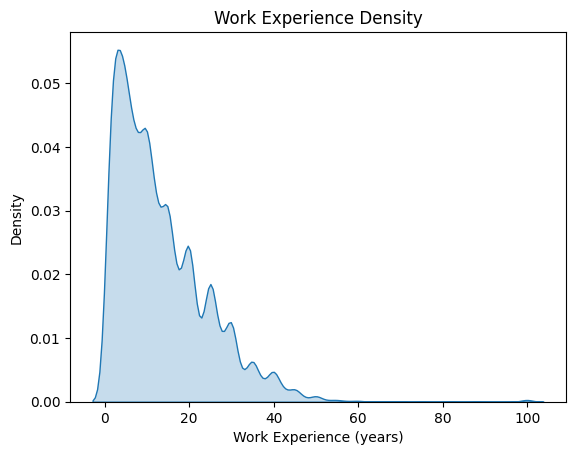

In [522]:
sns.kdeplot(df["WorkExp"], fill=True)
plt.xlabel("Work Experience (years)")
plt.title("Work Experience Density")
plt.show()

In [523]:
#Identify rows where years of experience is greater than age (max_age is set to -1 for those who prefer not to say or have missing age)
df_max_age = df.copy()
df_max_age["max_age"] = df["Age"].apply(lambda x: int(x.split("-")[1].split(" ")[0]) if "-" in x else int(x.split(" ")[0]) if x != "Prefer not to say" else -1)
df_max_age[(df_max_age["WorkExp"] > df_max_age["max_age"]) & (df_max_age["max_age"] != -1)]

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,AIAgentOrchWrite,AIAgentObserveSecure,AIAgentObsWrite,AIAgentExternal,AIAgentExtWrite,AIHuman,AIOpen,ConvertedCompYearly,JobSat,max_age
1851,1852,I am a developer by profession,25-34 years old,Primary/elementary school,Not employed,Attending school (full-time),44.0,"Yes, I am not new to coding but am learning ne...","School (i.e., University, College, etc)","Yes, I learned how to use AI-enabled tools req...",...,NaN,NaN,NaN,NaN,NaN,When I’m stuck and can’t explain the problem,6,NaN,NaN,34
2056,2057,I am a developer by profession,18-24 years old,Some college/university study without earning ...,Employed,Transitioning to retirement (gradually reducin...,50.0,"No, I am not new to coding and did not learn n...",NaN,"No, I didn't spend time learning in the past year",...,NaN,NaN,NaN,NaN,NaN,When I want to fully understand something;When...,NaN,136450.0,7.0,24
3285,3286,I code primarily as a hobby,65 years or older,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Retired,None of the above,100.0,"No, I am not new to coding and did not learn n...",NaN,"No, I learned something that was not related t...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65
4933,4934,I am a developer by profession,45-54 years old,Other (please specify):,I prefer not to say,NaN,100.0,"Yes, I am new to coding or currently a student",Other (please specify):,"No, I didn't spend time learning in the past year",...,NaN,NaN,NaN,NaN,NaN,Other (please specify):,FUCK SUPPORT FROM SO!,NaN,0.0,54
5430,5431,"I am not primarily a developer, but I write co...",65 years or older,"Professional degree (JD, MD, Ph.D, Ed.D, etc.)",Retired,Attending school (part-time),68.0,"No, I am not new to coding and did not learn n...",NaN,"No, I didn't spend time learning in the past year",...,chatgbt,NaN,NaN,ChatGPT,NaN,When I want to compare different solutions;Whe...,Knowing how to recognize insecure code.,NaN,NaN,65
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
47558,47559,I work with developers or my work supports dev...,25-34 years old,Other (please specify):,Student,Engaged in paid work (less than 10 hours per w...,100.0,"Yes, I am not new to coding but am learning ne...",Colleague or on-the-job training;Other (please...,"No, I didn't spend time learning in the past year",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34
47601,47602,"I am not primarily a developer, but I write co...",25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Student,Engaged in paid work (10-19 hours per week),100.0,"Yes, I am new to coding or currently a student",Colleague or on-the-job training,"Yes, I learned how to use AI-enabled tools req...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34
48208,48209,I am a developer by profession,65 years or older,Other (please specify):,Retired,"Caring for dependents (children, elderly, etc....",69.0,"No, I am not new to coding and did not learn n...",NaN,"No, I learned something that was not related t...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,65
48454,48455,I am a developer by profession,25-34 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,48.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,34


In [524]:
df.groupby("WorkExp")[["ConvertedCompYearly"]].median().sort_values(by="ConvertedCompYearly", ascending=False).round(2)

,ConvertedCompYearly
WorkExp,
99.0,294752.0
57.0,260000.0
61.0,160000.0
41.0,145000.0
37.0,139218.0
...,...
66.0,NaN
69.0,NaN
70.0,NaN


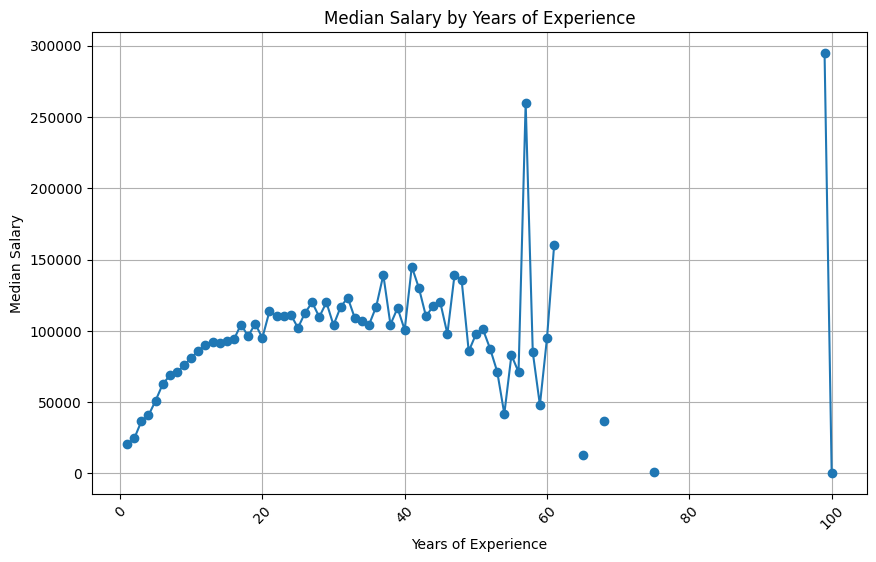

In [525]:
# line graph of median salary by years of experience
median_salary_by_exp = df.groupby("WorkExp")["ConvertedCompYearly"].median()
plt.figure(figsize=(10, 6))
median_salary_by_exp.plot(kind='line', marker='o')
plt.title("Median Salary by Years of Experience")
plt.xlabel("Years of Experience")
plt.ylabel("Median Salary")
plt.xticks(rotation=45)
plt.grid()
plt.show()



**Insights**

* Most of the responders have 0-20 years of experience
* Some entries have very high years of experience and could be invalid
* some entries have higher years of experience than maximum possible age, this could be invalid
* There is an upward trend in Salary as WorkExp increases until around 50 years and then it gets more varied 

### RemoteWork


In [526]:
df["RemoteWork"].isna().sum()


np.int64(15411)

In [527]:
df_remote= df[df["RemoteWork"].notnull()].copy()
df_remote["RemoteWork"].value_counts()

RemoteWork
Remote                                                                          10931
Hybrid (some remote, leans heavy to in-person)                                   6732
In-person                                                                        6042
Hybrid (some in-person, leans heavy to flexibility)                              5831
Your choice (very flexible, you can come in when you want or just as needed)     4244
Name: count, dtype: int64

In [528]:
df_remote.groupby("RemoteWork")[["ConvertedCompYearly"]].median().sort_values(by="ConvertedCompYearly", ascending=False).round(2)

,ConvertedCompYearly
RemoteWork,
Remote,88492.0
"Hybrid (some in-person, leans heavy to flexibility)",80966.0
"Your choice (very flexible, you can come in when you want or just as needed)",75410.0
"Hybrid (some remote, leans heavy to in-person)",72958.0
In-person,46406.0


Text(0.5, 0, 'Median Salary')

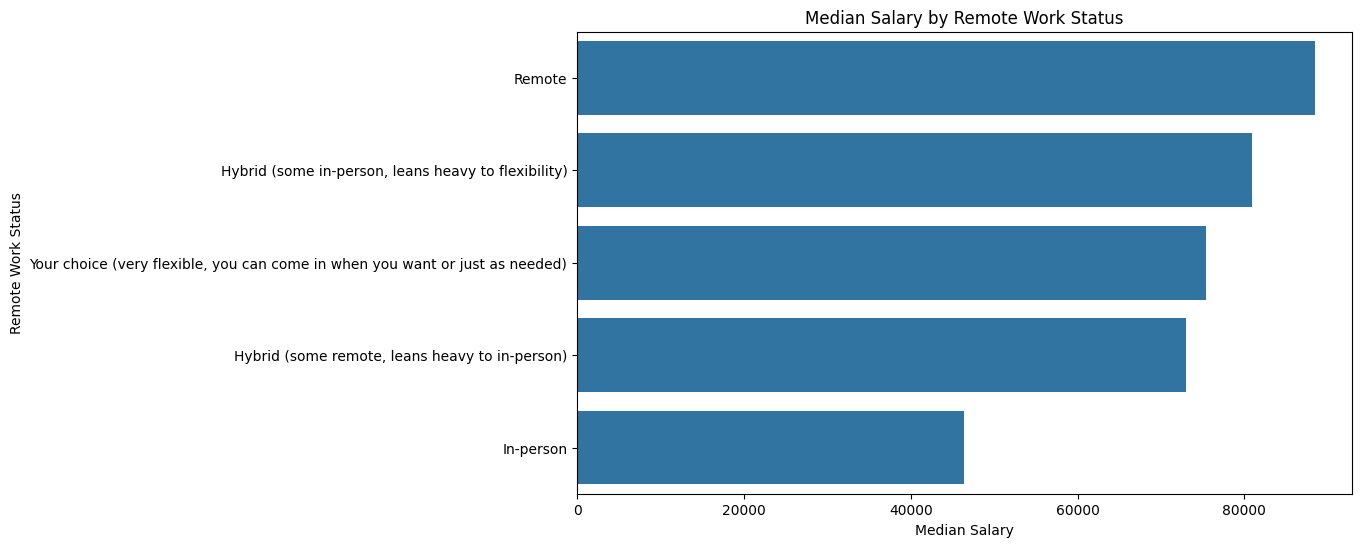

In [529]:
#median salary by remote work status 

median_salary_remote = df_remote.groupby("RemoteWork")["ConvertedCompYearly"].median().sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(y=median_salary_remote.index, x=median_salary_remote.values)
plt.title("Median Salary by Remote Work Status")
plt.ylabel("Remote Work Status")
#plt.xticks(rotation=45)
plt.xlabel("Median Salary")

**Insights**

* Remote work has the highest median and Hybrid/Flixble are not that far behind
* In-person median salary is significantly less

### DevType

In [530]:
df['DevType'].isna().sum()

np.int64(5511)

In [531]:
df["DevType"].value_counts()

DevType
Developer, full-stack                            12351
Developer, back-end                               6453
Student                                           3008
Architect, software or solutions                  2684
Developer, front-end                              1974
Developer, desktop or enterprise applications     1919
Other (please specify):                           1825
Developer, mobile                                 1391
Developer, embedded applications or devices       1274
Academic researcher                               1131
Engineering manager                               1068
DevOps engineer or professional                   1053
Data engineer                                      770
AI/ML engineer                                     677
Data scientist                                     574
Senior executive (C-suite, VP, etc.)               528
System administrator                               480
Retired                                            458
De

<Axes: ylabel='DevType'>

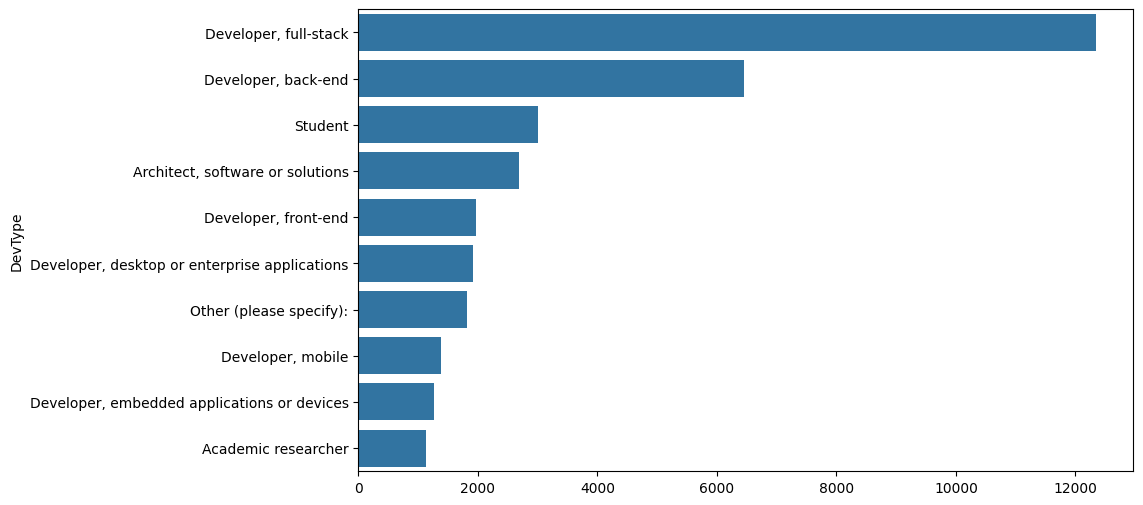

In [532]:
#plot of distribution of respondents by devtype
plt.figure(figsize=(10, 6))
devtype_counts = df["DevType"].value_counts().head(10)
sns.barplot(y=devtype_counts.index, x=devtype_counts.values)



In [533]:
DevType_comp = df.groupby("DevType")[["ConvertedCompYearly"]].median().sort_values(by="ConvertedCompYearly", ascending=False).round(2)
print(DevType_comp)

                                               ConvertedCompYearly
DevType                                                           
Senior executive (C-suite, VP, etc.)                      139218.0
Engineering manager                                       130000.0
Product manager                                           104413.0
Cloud infrastructure engineer                             103112.5
Architect, software or solutions                          100962.0
Cybersecurity or InfoSec professional                      98827.0
Applied scientist                                          98612.0
Founder, technology or otherwise                           92786.0
AI/ML engineer                                             87280.5
DevOps engineer or professional                            87011.0
Database administrator or engineer                         85769.0
Data scientist                                             81210.0
Data engineer                                              808

Text(0.5, 1.0, 'Median Salary by Developer Type')

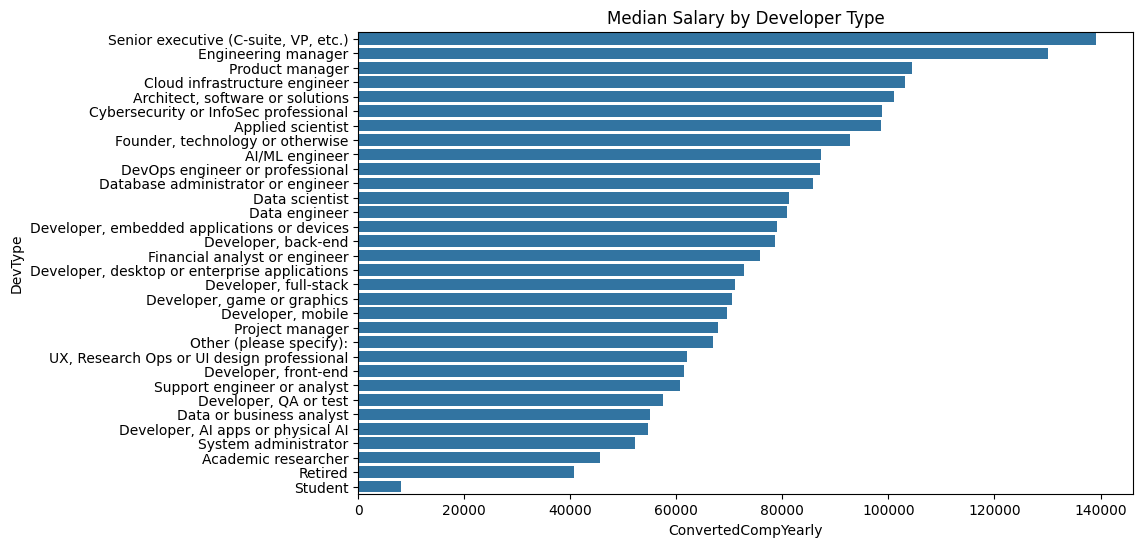

In [534]:
#plot of Devtype_comp
plt.figure(figsize=(10, 6))
sns.barplot(y=DevType_comp.index, x=DevType_comp["ConvertedCompYearly"])
plt.title("Median Salary by Developer Type")


**Insights**
* The positions or DevType with highest median salaries :
* * Senior executive (C-suite, VP, etc.)                      139218.0
* * Engineering manager                                       130000.0
* * Product manager                                           104413.0
* * Cloud infrastructure engineer                             103112.5
* * Architect, software or solutions                          100962.0

### LanguageHaveWorkedWith

In [535]:
df['LanguageHaveWorkedWith'].isna().sum()

np.int64(17520)

In [536]:
df_eda['Language_Sorted'] = df_eda['LanguageHaveWorkedWith'].apply(
    lambda x: ';'.join(sorted(str(x).split(';'))) if pd.notna(x) else x
)

In [537]:
language_dummies = df_eda['LanguageHaveWorkedWith'].str.get_dummies(sep=';')
language_dummies = df_eda['Language_Sorted'].str.get_dummies(sep=';')
df_eda = pd.concat([df_eda, language_dummies], axis=1)
df_eda.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,R,Ruby,Rust,SQL,Scala,Swift,TypeScript,VBA,Visual Basic (.Net),Zig
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,1,0,0,0,0,0,0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,0,0,0,0,0,0,0
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,0,0,0,1,0,0,0
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,0,0,0,1,0,0,0,0,0,0
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,1,0,0,1,1,1,0


JavaScript                 21005
HTML/CSS                   19698
SQL                        18633
Python                     18410
Bash/Shell (all shells)    15503
TypeScript                 13859
Java                        9358
C#                          8852
C++                         7485
PowerShell                  7371
C                           6987
PHP                         5994
Go                          5219
Rust                        4724
Kotlin                      3420
Lua                         2910
Assembly                    2246
Ruby                        2046
Dart                        1885
Swift                       1719
R                           1569
Groovy                      1535
Visual Basic (.Net)         1409
VBA                         1334
MATLAB                      1231
Perl                        1215
GDScript                    1062
Elixir                       847
Scala                        843
Delphi                       796
Lisp      

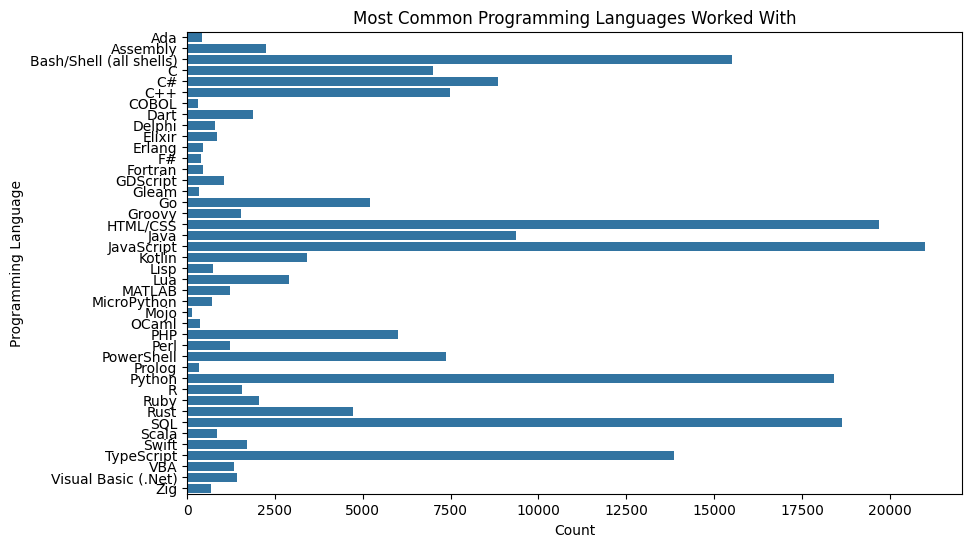

In [538]:
counts = df_eda[language_dummies.columns].sum() 
print(counts.sort_values(ascending=False))

plt.figure(figsize=(10,6))

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.title("Most Common Programming Languages Worked With")
plt.xlabel("Count")
plt.ylabel("Programming Language")
plt.show()

**Insights**
* The most common programming languages are 
* * JavaScript                 21005
* * HTML/CSS                   19698
* * SQL                        18633
* * Python                     18410
* * Bash/Shell (all shells)    15503
* * TypeScript                 13859

### LearnCodeAI

In [539]:
#Combine all 'Yes' responses in LearnCodeAI into one category and all 'No' responses into another category
learn_code_ai_df = df[df["LearnCodeAI"].notnull()].copy()
learn_code_ai_df["LearnCodeAIBinary"] = learn_code_ai_df["LearnCodeAI"].apply(lambda x: "Yes" if "Yes" in str(x) else "No")
learn_code_ai_df.groupby("LearnCodeAIBinary")[["ConvertedCompYearly"]].median().round(2).sort_values(by="ConvertedCompYearly", ascending=False)

,ConvertedCompYearly
LearnCodeAIBinary,
Yes,77000.0
No,70657.5


**Insights**
* Those who studied AI in 2025 have higher salary median 
* however, the difference is not much

### LearnCode

In [540]:
df['LearnCode'].isna().sum()

np.int64(15635)

In [541]:
df_eda['LearnCode_Sorted'] = df_eda['LearnCode'].apply(
    lambda x: ';'.join(sorted(str(x).split(';'))) if pd.notna(x) else x
)

In [542]:
lc_dummies = df_eda['LearnCode'].str.get_dummies(sep=';')
lc_dummies.head()
df_eda = pd.concat([df_eda, lc_dummies], axis=1)
df_eda.head()

,ResponseId,MainBranch,Age,EdLevel,Employment,EmploymentAddl,WorkExp,LearnCodeChoose,LearnCode,LearnCodeAI,...,Coding Bootcamp,Colleague or on-the-job training,Games or coding challenges,Online Courses or Certification (includes all media types),Other (please specify):,"Other online resources (e.g. standard search, forum, online community)","School (i.e., University, College, etc)",Stack Overflow or Stack Exchange,Technical documentation (is generated for/by the tool or system),Videos (not associated with specific online course or certification)
0,1,I am a developer by profession,25-34 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)",Employed,"Caring for dependents (children, elderly, etc.)",8.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,1,0,1,0,0,0,0
1,2,I am a developer by profession,25-34 years old,"Associate degree (A.A., A.S., etc.)",Employed,NaN,2.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,1,0,1,0,1,0,1
2,3,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)","Independent contractor, freelancer, or self-em...",None of the above,10.0,"Yes, I am not new to coding but am learning ne...",Online Courses or Certification (includes all ...,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,1,0,0,0,0,1,1
3,4,I am a developer by profession,35-44 years old,"Bachelor’s degree (B.A., B.S., B.Eng., etc.)",Employed,None of the above,4.0,"Yes, I am not new to coding but am learning ne...","Other online resources (e.g. standard search, ...","Yes, I learned how to use AI-enabled tools for...",...,0,0,0,0,0,1,0,1,1,1
4,5,I am a developer by profession,35-44 years old,"Master’s degree (M.A., M.S., M.Eng., MBA, etc.)","Independent contractor, freelancer, or self-em...","Caring for dependents (children, elderly, etc.)",21.0,"No, I am not new to coding and did not learn n...",NaN,"Yes, I learned how to use AI-enabled tools for...",...,0,0,0,0,0,0,0,0,0,0


Technical documentation (is generated for/by the tool or system)          22739
Other online resources (e.g. standard search, forum, online community)    19701
Stack Overflow or Stack Exchange                                          17245
Videos (not associated with specific online course or certification)      16771
AI CodeGen tools or AI-enabled apps                                       14753
Blogs or podcasts                                                         11688
Online Courses or Certification (includes all media types)                10973
Books / Physical media                                                    10187
Colleague or on-the-job training                                           8596
School (i.e., University, College, etc)                                    5561
Games or coding challenges                                                 4046
Coding Bootcamp                                                            1747
Other (please specify):                 

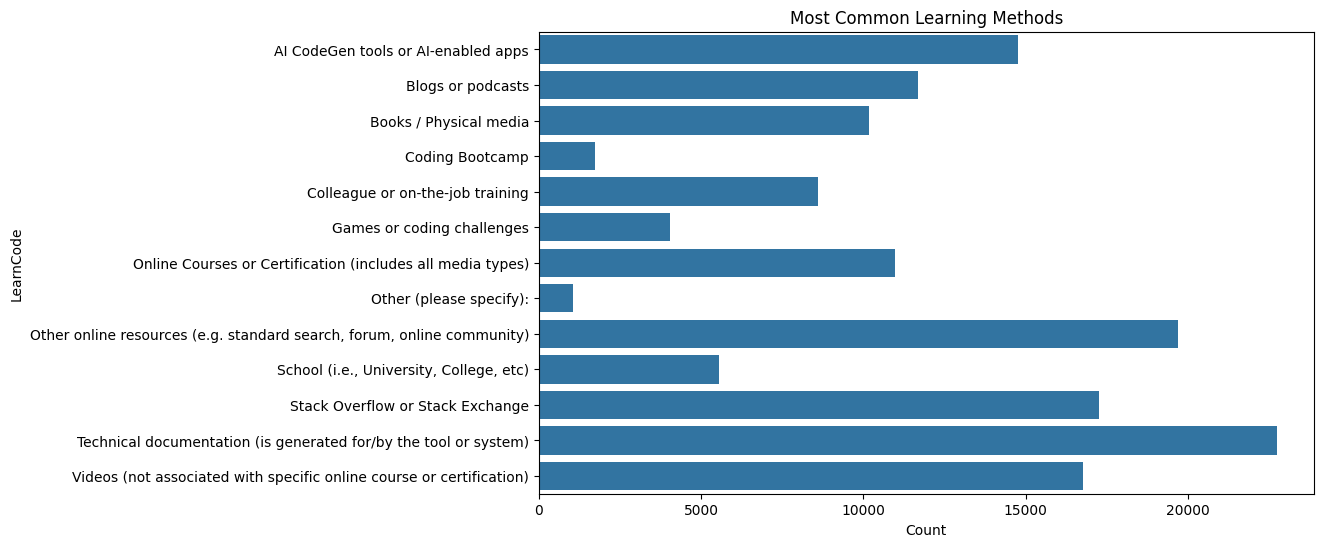

In [543]:
counts = df_eda[lc_dummies.columns].sum() 
print(counts.sort_values(ascending=False))

plt.figure(figsize=(10,6))

sns.barplot(
    x=counts.values,
    y=counts.index
)

plt.title("Most Common Learning Methods")
plt.xlabel("Count")
plt.ylabel("LearnCode")
plt.show()

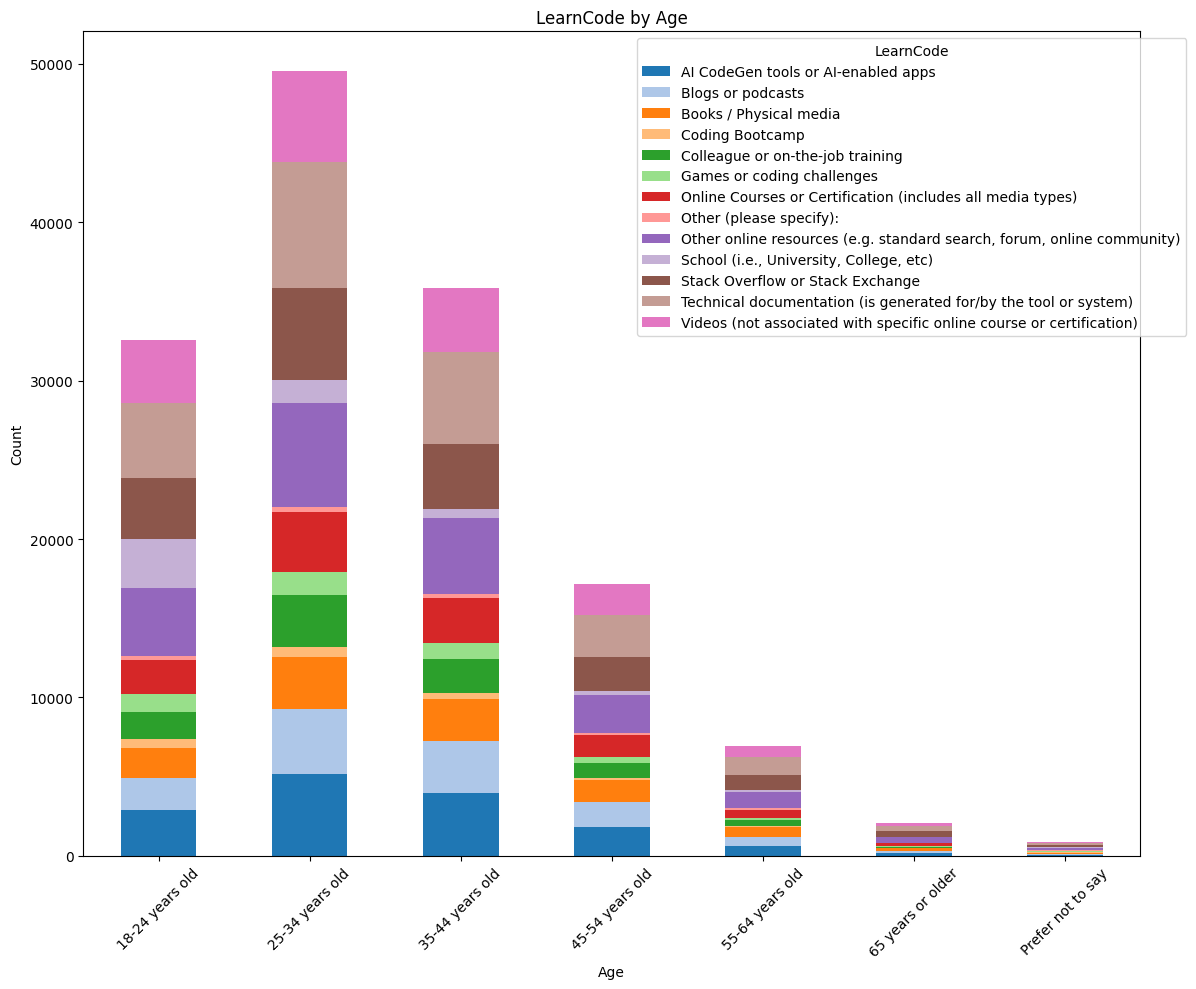

In [544]:
age_learn = df_eda.groupby("Age")[lc_dummies.columns].sum()

colors = sns.color_palette("tab20", n_colors=len(age_learn.columns))

age_learn.plot(
    kind="bar",
    stacked=True,
    figsize=(12,10),
    color=colors
)

plt.title("LearnCode by Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.legend(title="LearnCode", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

<Axes: xlabel='EdLevel', ylabel='count'>

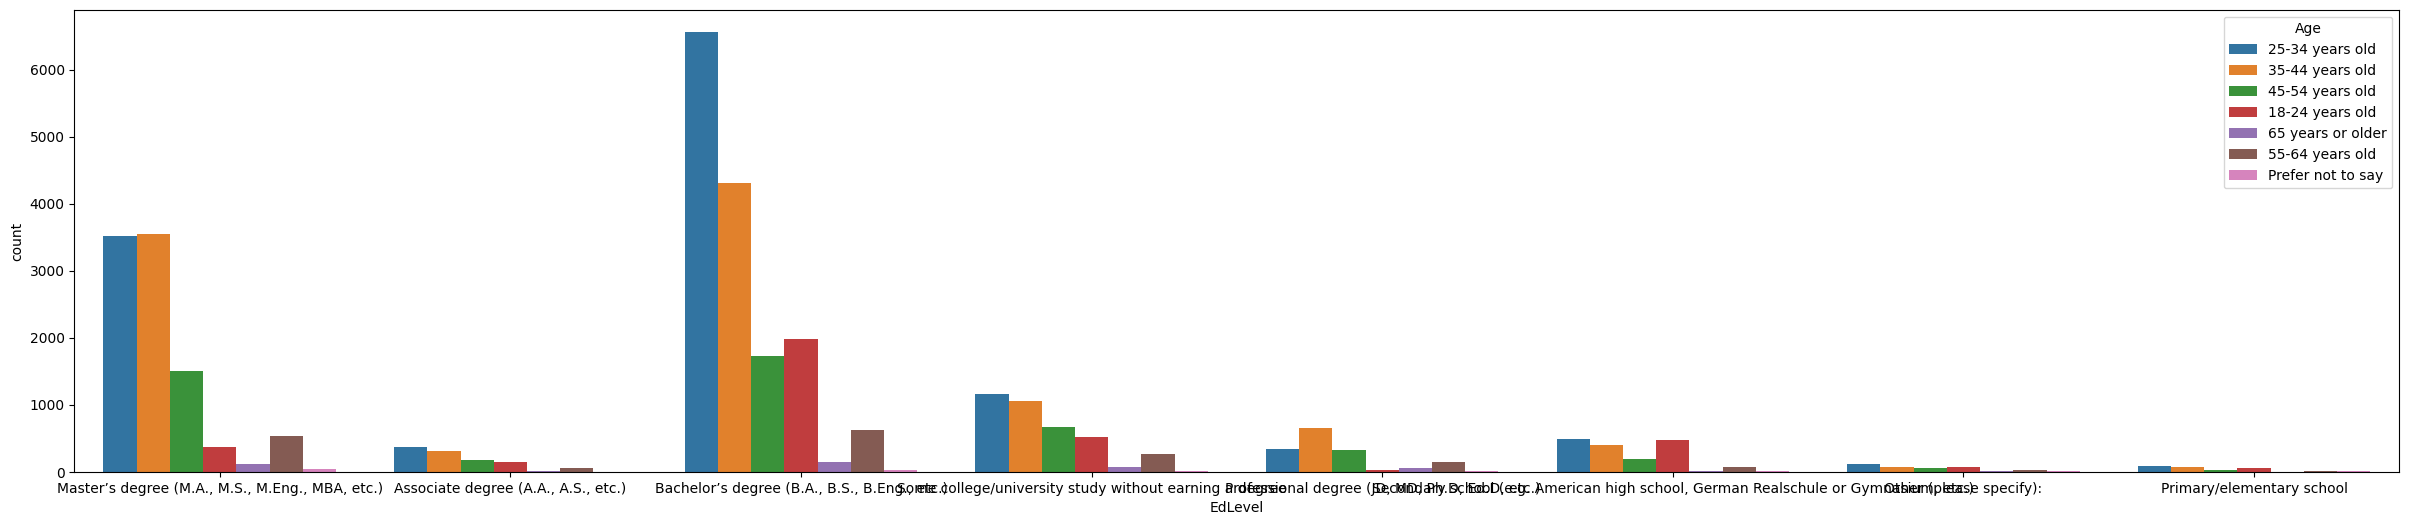

In [545]:
plt.figure(figsize=(30, 6))
df_eda.rename(columns={"School (i.e., University, College, etc)": "School"}, inplace=True)
sns.countplot(data=df_eda[(df_eda["School"] == False) & (df_eda["MainBranch"] == "I am a developer by profession")], x="EdLevel", hue="Age")


** Insights **
* The most popular ways of learning to code are
* * Technical documentation (is generated for/by the tool or system)          22739
* * Other online resources (e.g. standard search, forum, online community)    19701
* * Stack Overflow or Stack Exchange                                          17245
* * Videos (not associated with specific online course or certification)      16771
* * AI CodeGen tools or AI-enabled apps                                       14753

## Summary



**Dataset General Info**


* Total Entries: 49191
* Number of Columns: 172
* Max values for WorkExp, YearsCode, ToolcountWork, and ToolCountPersonal are probably invalid


**Missing Values and Response Rates**


* ConvertedCompYearly missing values: 51.32% 
* CompTotal missing value: 49.45% 
* Possible source of discrepancy is missing country or currency
* A lot of AI-related questions have low (e.g. less than 30%) response from the participants. 


**ConvertedCompYearly**


* ConvertedCompYearly Median: 75320.0
* ConvertedCompYearly Mean: 101761.53990061386
* Lower Middle 50%: 38171.0
* Upper Middle 50%: 120596.0


ConvertedCompYearly is extremely skewed to the right.
The values accross countries vary greatly. It might be good to limit the scope geographically

**Country**


Countries with most responders: USA, Germany, India, UK, and France
Geographic location plays a role in median salary

**MainBranch**


Most of Responders are developers by profession: 37467 (76%)
Those who write code sometimes and students: 4894 (10%)


**Age**


most respondents are between 25-44 years old
25-34: 33.6%
35-44: 26.9%
18-24: 18.7%


Median salaries are increasing with Age and peaks at 55-64 years old

	
**EdLevel**


So mostly people have Bachelor's or Master's degree.
Higher Edlevel shows higher median salary, however the increase is not drastic


**Employement**


* A big majority of respondents are employed or freelaner
* * Employed                                                33750
* * Independent contractor, freelancer, or self-employed     6708
* * Student                                                  4428


**EmployementAddl**


50% of all employed people have other activities, like volunteering, caring for dependents and so on. Students usually are just studying, though 50% are working, volunteering as well.  


**WorkExp**


* Most of the responders have 0-20 years of experience
* Some entries have very high years of experience and could be invalid
* some entries have higher years of experience than maximum possible age, this could be invalid
* There is an upward trend in Salary as WorkExp increases until around 50 years and then it gets more varied


**RemoteWork**


* Remote work has the highest median and Hybrid/Flixble are not that far behind
* In-person median salary is significantly less


**DevType**


* The positions or DevType with highest median salaries :
* * Senior executive (C-suite, VP, etc.)                      139218.0
* * Engineering manager                                       130000.0
* * Product manager                                           104413.0
* * Cloud infrastructure engineer                             103112.5
* * Architect, software or solutions                          100962.0


**LanguangeHaveWorkedWith**


* The most common programming languages are
* * JavaScript                 21005
* * HTML/CSS                   19698
* * SQL                        18633
* * Python                     18410
* * Bash/Shell (all shells)    15503
* * TypeScript                 13859


**LearnCodeAI**


* Those who studied AI in 2025 have higher salary median
* however, the difference is not much


**LearnCode**


* The most popular ways of learning to code are
* * Technical documentation (is generated for/by the tool or system)          22739
* * Other online resources (e.g. standard search, forum, online community)    19701
* * Stack Overflow or Stack Exchange                                          17245
* * Videos (not associated with specific online course or certification)      16771
* * AI CodeGen tools or AI-enabled apps                                       14753

